In [ ]:
import numpy as np
import cv2
import os
import json
import shutil
from sklearn.model_selection import train_test_split
import pydicom
import VGG16
from tensorflow.keras import layers, models

In [2]:
def load_prepocess_dicom_vgg16(file_path):
    try:
        # Load DICOM file
        dicom = pydicom.dcmread(file_path)
        image = dicom.pixel_array

        image = image.astype(np.float32)

        image_min = np.min(image)
        image_max = np.max(image)

        if image_max - image_min != 0:
            image = (image - image_min) / (image_max - image_min)
        else:
            image = np.zeros_like(image)

        image_resized = cv2.resize(image, (224, 224))
        image_rgb = np.stack((image_resized,)*3, axis=-1)
        return image_rgb

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
        return None
        

Successfully accessed file: \\?\C:\Dokumentumok\hello\pneumonia_detector_ML_project\pneumonia_detection_CNN\data\train\pneumonia\1.2.276.0.7230010.3.1.4.8323329.1752.1517874292.676355.dcm


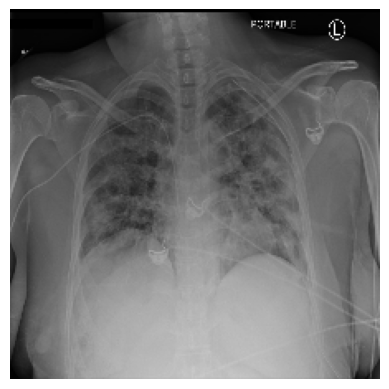

In [3]:
import matplotlib.pyplot as plt

target = "C:\\Dokumentumok\\hello\\pneumonia_detector_ML_project\\pneumonia_detection_CNN\\data\\train\\pneumonia\\1.2.276.0.7230010.3.1.4.8323329.1752.1517874292.676355.dcm"

if not target.startswith("\\\\?\\"):
                target = "\\\\?\\" + target

if os.path.exists(target):
    print(f"Successfully accessed file: {target}")


processed_image = load_prepocess_dicom_vgg16(target)
plt.imshow(processed_image.squeeze(), cmap='gray')
plt.axis('off')
plt.show()
